# Proyecto Aliados Frescos — Grupo 1
## La red que no logra seguirle el paso a la ciudad

Solución integral de optimización de la distribución de última milla, abordando los **cuatro frentes de decisión** del caso con los enfoques vistos en el curso:

| Frente | Problema | Enfoque |
|---|---|---|
| 1 | Optimización de recorridos | Simulated Annealing · A* · IDA* |
| 2 | Reasignación de zonas | Simulated Annealing (T alta, enfriamiento lento) |
| 3 | Reabastecimiento diario bajo incertidumbre | MDP · Policy Iteration |
| 4 | Política de inventario a largo plazo | Policy Iteration (sensibilidad y generalización) |

---
### 0. Configuración e importación de librerías

In [1]:
import numpy as np
import pandas as pd
import math
import random
import heapq
import time
from itertools import combinations
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


### 1. Generación y preparación de datos
Red logística (puntos de venta + centro de distribución), matriz de distancias y demanda histórica reproducible.

In [2]:
def generar_red_logistica(n_puntos=60, n_cuadrillas=4, semilla=SEED):
    rng = np.random.default_rng(semilla)
    centro = np.array([0.0, 0.0])
    coords = rng.uniform(-25, 25, size=(n_puntos, 2))
    coords = np.vstack([centro, coords])
    ids = ["CD"] + [f"P{i:02d}" for i in range(1, n_puntos + 1)]
    df = pd.DataFrame(coords, columns=["x", "y"])
    df["id"] = ids
    df["tipo"] = ["CD"] + list(rng.choice(["tienda", "surtimax", "carulla"], size=n_puntos, p=[0.6, 0.25, 0.15]))
    apertura = rng.choice([5, 6, 7], size=n_puntos)
    df.loc[1:, "ventana_ini"] = apertura
    df.loc[1:, "ventana_fin"] = apertura + rng.choice([2, 3], size=n_puntos)
    df.loc[0, ["ventana_ini", "ventana_fin"]] = [0, 24]
    df["cuadrilla_actual"] = [-1] + list(rng.integers(0, n_cuadrillas, size=n_puntos))
    return df

def matriz_distancias(df):
    P = df[["x", "y"]].to_numpy()
    diff = P[:, None, :] - P[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

def generar_demanda_historica(n_puntos=60, n_dias=180, semilla=SEED):
    rng = np.random.default_rng(semilla + 1)
    dias = np.arange(n_dias)
    base = rng.uniform(20, 80, size=n_puntos)
    demanda = np.zeros((n_dias, n_puntos))
    for p in range(n_puntos):
        estacional = 1 + 0.3 * np.sin(2 * np.pi * dias / 7)
        quincena = np.where((dias % 15 == 0) | (dias % 30 == 0), 1.4, 1.0)
        ruido = rng.normal(1.0, 0.15, size=n_dias)
        demanda[:, p] = np.clip(base[p] * estacional * quincena * ruido, 0, None)
    return demanda.round().astype(int)

red = generar_red_logistica()
DIST = matriz_distancias(red)
DEMANDA = generar_demanda_historica()

print("Puntos de venta (incluye CD):", len(red))
print("Matriz de distancias:", DIST.shape)
print("Demanda histórica:", DEMANDA.shape, "(dias x puntos)")
red.head()


Puntos de venta (incluye CD): 61
Matriz de distancias: (61, 61)
Demanda histórica: (180, 60) (dias x puntos)


,x,y,id,tipo,ventana_ini,ventana_fin,cuadrilla_actual
0,0.000000,0.000000,CD,CD,0.0,24.0,-1
1,13.697802,-3.056078,P01,tienda,7.0,10.0,1
2,17.929896,9.868401,P02,surtimax,7.0,10.0,3
3,-20.291133,23.781118,P03,tienda,5.0,8.0,1
4,13.056985,14.303215,P04,tienda,7.0,10.0,3


---
## Frente 1 — Optimización de recorridos de distribución

### 2.1 Representación del problema de ruta (TSP)
Modelo del recorrido de un vehículo con retorno al centro de distribución y heurística euclidiana admisible.

In [3]:
class ProblemaRuta:
    def __init__(self, indices_puntos, dist, deposito=0):
        self.puntos = list(indices_puntos)
        self.dist = dist
        self.deposito = deposito

    def costo_ruta(self, orden):
        ruta = [self.deposito] + list(orden) + [self.deposito]
        return sum(self.dist[ruta[i], ruta[i + 1]] for i in range(len(ruta) - 1))

    def estado_aleatorio(self):
        s = self.puntos[:]
        random.shuffle(s)
        return s

    def f(self, orden):
        return -self.costo_ruta(orden)

    def vecino_aleatorio(self, orden):
        s = list(orden)
        i, j = random.sample(range(len(s)), 2)
        s[i], s[j] = s[j], s[i]
        return s

    def vecindad(self, orden):
        vecinos = []
        for i in range(len(orden)):
            for j in range(i + 1, len(orden)):
                s = list(orden)
                s[i], s[j] = s[j], s[i]
                vecinos.append(s)
        return vecinos


def heuristica_euclidiana(actual, pendientes, deposito, dist):
    if not pendientes:
        return dist[actual, deposito]
    al_mas_cercano = min(dist[actual, p] for p in pendientes)
    regreso = min(dist[p, deposito] for p in pendientes)
    return al_mas_cercano + regreso


### 2.2 Simulated Annealing
Metaheurística que acepta empeoramientos con probabilidad decreciente para escapar de óptimos locales.

In [4]:
def simulated_annealing(prob, T0=100.0, alpha=0.995, Tmin=0.01, max_iter=20000):
    s = prob.estado_aleatorio()
    mejor = s
    T = T0
    it = 0
    while T > Tmin and it < max_iter:
        vecino = prob.vecino_aleatorio(s)
        delta = prob.f(vecino) - prob.f(s)
        if delta > 0 or random.random() < math.exp(delta / T):
            s = vecino
        if prob.f(s) > prob.f(mejor):
            mejor = s
        T *= alpha
        it += 1
    return mejor


def resolver_ruta_sa(indices, dist, **kwargs):
    prob = ProblemaRuta(indices, dist)
    t0 = time.perf_counter()
    orden = simulated_annealing(prob, **kwargs)
    t1 = time.perf_counter()
    return {
        "orden": orden,
        "costo": prob.costo_ruta(orden),
        "tiempo_ms": (t1 - t0) * 1000,
    }


### 2.3 A* e IDA*
Búsqueda informada en grafos con `f = g + h`. A* garantiza optimalidad; IDA* reduce el uso de memoria.

In [5]:
def a_estrella_ruta(indices, dist, deposito=0):
    puntos = frozenset(indices)
    inicio = (deposito, frozenset())
    g_inicio = 0
    h_inicio = heuristica_euclidiana(deposito, puntos, deposito, dist)
    frontera = [(h_inicio, g_inicio, deposito, frozenset(), [deposito])]
    explorados = {}
    while frontera:
        f, g, actual, visitados, camino = heapq.heappop(frontera)
        if visitados == puntos:
            costo_total = g + dist[actual, deposito]
            return camino[1:] , costo_total
        clave = (actual, visitados)
        if clave in explorados and explorados[clave] <= g:
            continue
        explorados[clave] = g
        for sig in puntos - visitados:
            g_nuevo = g + dist[actual, sig]
            nuevos_visitados = visitados | {sig}
            pendientes = puntos - nuevos_visitados
            h = heuristica_euclidiana(sig, pendientes, deposito, dist)
            heapq.heappush(frontera, (g_nuevo + h, g_nuevo, sig, nuevos_visitados, camino + [sig]))
    return None, float("inf")


def ida_estrella_ruta(indices, dist, deposito=0):
    puntos = frozenset(indices)
    cutoff = heuristica_euclidiana(deposito, puntos, deposito, dist)
    mejor_camino = [None]

    def buscar(actual, visitados, g, cutoff, camino):
        if visitados == puntos:
            f = g + dist[actual, deposito]
            if f > cutoff:
                return f
            mejor_camino[0] = camino[1:]
            return "ENCONTRADO"
        pendientes = puntos - visitados
        f = g + heuristica_euclidiana(actual, pendientes, deposito, dist)
        if f > cutoff:
            return f
        minimo = float("inf")
        for sig in pendientes:
            g_nuevo = g + dist[actual, sig]
            r = buscar(sig, visitados | {sig}, g_nuevo, cutoff, camino + [sig])
            if r == "ENCONTRADO":
                return "ENCONTRADO"
            if r < minimo:
                minimo = r
        return minimo

    while True:
        r = buscar(deposito, frozenset(), 0, cutoff, [deposito])
        if r == "ENCONTRADO":
            ruta = mejor_camino[0]
            costo = sum(dist[([deposito] + ruta + [deposito])[i], ([deposito] + ruta + [deposito])[i + 1]]
                        for i in range(len(ruta) + 1))
            return ruta, costo
        if r == float("inf"):
            return None, float("inf")
        cutoff = r


### 2.4 Experimento comparativo y recalibración
SA sobre la instancia grande (única viable en tiempo real) y comparación exacta SA vs A* vs IDA* sobre una instancia pequeña.

In [6]:
def experimento_frente1(red, dist, n_grande=25, n_exacto=7, semilla=SEED):
    rng = np.random.default_rng(semilla + 5)

    # Instancia grande (decenas de puntos): solo SA es viable en tiempo real
    idx_grande = list(rng.choice(range(1, len(red)), size=n_grande, replace=False))
    prob_g = ProblemaRuta(idx_grande, dist)
    t0 = time.perf_counter()
    orden_sa_g = simulated_annealing(prob_g)
    t_sa_g = (time.perf_counter() - t0) * 1000
    costo_sa_g = prob_g.costo_ruta(orden_sa_g)

    # Instancia pequeña: comparacion exacta SA vs A* vs IDA*
    idx_exacto = idx_grande[:n_exacto]
    prob_e = ProblemaRuta(idx_exacto, dist)

    t0 = time.perf_counter(); orden_sa_e = simulated_annealing(prob_e); t_sa_e = (time.perf_counter() - t0) * 1000
    costo_sa_e = prob_e.costo_ruta(orden_sa_e)
    t0 = time.perf_counter(); _, costo_a = a_estrella_ruta(idx_exacto, dist); t_a = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter(); _, costo_ida = ida_estrella_ruta(idx_exacto, dist); t_ida = (time.perf_counter() - t0) * 1000

    tabla_exacto = pd.DataFrame([
        ("Simulated Annealing", costo_sa_e, t_sa_e),
        ("A*", costo_a, t_a),
        ("IDA*", costo_ida, t_ida),
    ], columns=["Algoritmo", "Distancia (km)", "Tiempo (ms)"])
    tabla_exacto["Gap vs optimo (%)"] = (tabla_exacto["Distancia (km)"] / tabla_exacto["Distancia (km)"].min() - 1) * 100

    return tabla_exacto, idx_grande, idx_exacto, costo_sa_g, t_sa_g, n_grande


def recalibracion_sa(indices, dist, n_cierres=5, semilla=SEED):
    rng = np.random.default_rng(semilla + 9)
    dist_mod = dist.copy()
    for _ in range(n_cierres):
        i, j = rng.choice(indices, size=2, replace=False)
        dist_mod[i, j] *= 3
        dist_mod[j, i] *= 3
    t0 = time.perf_counter()
    orden = simulated_annealing(ProblemaRuta(indices, dist_mod), T0=50, alpha=0.99)
    t = (time.perf_counter() - t0) * 1000
    return ProblemaRuta(indices, dist_mod).costo_ruta(orden), t


tabla_f1, idx_grande_f1, idx_exacto_f1, costo_sa_grande, t_sa_grande, n_grande_f1 = experimento_frente1(red, DIST)
costo_recal, t_recal = recalibracion_sa(idx_grande_f1, DIST)

print("FRENTE 1 - Optimizacion de recorridos")
print(f"\nInstancia grande ({n_grande_f1} puntos) - solo SA es viable:")
print(f"  Distancia: {costo_sa_grande:.2f} km | Tiempo: {t_sa_grande:.1f} ms")
print(f"\nInstancia pequena ({len(idx_exacto_f1)} puntos) - comparacion exacta:")
print(tabla_f1.to_string(index=False))
print(f"\nRecalibracion SA ante cierres viales ({n_grande_f1} puntos): {costo_recal:.2f} km en {t_recal:.1f} ms")


FRENTE 1 - Optimizacion de recorridos

Instancia grande (25 puntos) - solo SA es viable:
  Distancia: 225.59 km | Tiempo: 89.9 ms

Instancia pequena (7 puntos) - comparacion exacta:
          Algoritmo  Distancia (km)  Tiempo (ms)  Gap vs optimo (%)
Simulated Annealing       107.83248      40.7599                0.0
                 A*       107.83248       7.2303                0.0
               IDA*       107.83248   10780.4189                0.0

Recalibracion SA ante cierres viales (25 puntos): 310.34 km en 39.5 ms


---
## Frente 2 — Reasignación de zonas de atención

### 3.1 Modelo de partición de la red en zonas
Asignación de puntos a cuadrillas minimizando el costo agregado de toda la red y equilibrando la carga.

In [7]:
class ProblemaZonas:
    def __init__(self, red, dist, n_cuadrillas=4, deposito=0):
        self.dist = dist
        self.n = n_cuadrillas
        self.deposito = deposito
        self.puntos = list(range(1, len(red)))

    def costo_ruta_aprox(self, asignados):
        if not asignados:
            return 0.0
        no_visitados = set(asignados)
        actual = self.deposito
        total = 0.0
        while no_visitados:
            sig = min(no_visitados, key=lambda p: self.dist[actual, p])
            total += self.dist[actual, sig]
            actual = sig
            no_visitados.remove(sig)
        return total + self.dist[actual, self.deposito]

    def costo_total(self, asignacion):
        zonas = {c: [] for c in range(self.n)}
        for p, c in zip(self.puntos, asignacion):
            zonas[c].append(p)
        distancia = sum(self.costo_ruta_aprox(zonas[c]) for c in zonas)
        tamanos = [len(zonas[c]) for c in zonas]
        penal_balance = np.std(tamanos) * 8.0 + sum(40.0 for t in tamanos if t == 0)
        return distancia + penal_balance

    def f(self, asignacion):
        return -self.costo_total(asignacion)

    def estado_aleatorio(self):
        return [random.randrange(self.n) for _ in self.puntos]

    def vecino_aleatorio(self, asignacion):
        s = list(asignacion)
        i = random.randrange(len(s))
        s[i] = random.randrange(self.n)
        return s


def reasignar_zonas_sa(red, dist, n_cuadrillas=4, T0=500.0, alpha=0.999, Tmin=0.1, max_iter=40000):
    prob = ProblemaZonas(red, dist, n_cuadrillas)
    t0 = time.perf_counter()
    asignacion = simulated_annealing(prob, T0=T0, alpha=alpha, Tmin=Tmin, max_iter=max_iter)
    t = (time.perf_counter() - t0) * 1000
    return prob, asignacion, t


### 3.2 Experimento: enfriamiento rápido vs. T alta + enfriamiento lento
Comparación frente a la zonificación actual para evidenciar el escape de óptimos locales.

In [8]:
def experimento_frente2(red, dist, n_cuadrillas=4):
    prob = ProblemaZonas(red, dist, n_cuadrillas)

    costo_inicial = prob.costo_total(red["cuadrilla_actual"].iloc[1:].tolist())

    _, asig_rapido, t_rapido = reasignar_zonas_sa(red, dist, n_cuadrillas, T0=10, alpha=0.95, Tmin=0.1, max_iter=5000)
    costo_rapido = prob.costo_total(asig_rapido)

    _, asig_lento, t_lento = reasignar_zonas_sa(red, dist, n_cuadrillas, T0=500, alpha=0.999, Tmin=0.1, max_iter=40000)
    costo_lento = prob.costo_total(asig_lento)

    tabla = pd.DataFrame([
        ("Zonificación actual", costo_inicial, 0.0),
        ("SA enfriamiento rápido", costo_rapido, t_rapido),
        ("SA T alta + enfriamiento lento", costo_lento, t_lento),
    ], columns=["Configuración", "Costo total red", "Tiempo (ms)"])
    tabla["Reducción vs actual (%)"] = (1 - tabla["Costo total red"] / costo_inicial) * 100
    return tabla, asig_lento, prob


tabla_f2, asig_final, prob_f2 = experimento_frente2(red, DIST)
print("FRENTE 2 — Reasignación de zonas de atención")
print(tabla_f2.to_string(index=False))

zonas = {c: [] for c in range(prob_f2.n)}
for p, c in zip(prob_f2.puntos, asig_final):
    zonas[c].append(p)
print("\nPuntos por cuadrilla:", {c: len(v) for c, v in zonas.items()})


FRENTE 2 — Reasignación de zonas de atención
                 Configuración  Costo total red  Tiempo (ms)  Reducción vs actual (%)
           Zonificación actual       825.754140       0.0000                 0.000000
        SA enfriamiento rápido       663.902509      87.1328                19.600463
SA T alta + enfriamiento lento       458.683093    8427.4504                44.452826

Puntos por cuadrilla: {0: 15, 1: 15, 2: 15, 3: 15}


---
## Frente 3 — Reabastecimiento diario bajo incertidumbre

### 4.1 Formulación del MDP
Estados (inventario), acciones (cantidad a enviar), transición estocástica (demanda) y recompensa (ingreso − merma − agotado).

In [9]:
class MDPReabastecimiento:
    def __init__(self, demanda_punto, inv_max=20, precio=5.0, costo_unit=2.0,
                 costo_merma=3.0, costo_agotado=4.0, gamma=0.95):
        self.inv_max = inv_max
        self.precio = precio
        self.costo_unit = costo_unit
        self.costo_merma = costo_merma
        self.costo_agotado = costo_agotado
        self.gamma = gamma
        self.S = list(range(inv_max + 1))
        self.A = list(range(inv_max + 1))
        self.dist_demanda = self._estimar_demanda(demanda_punto)

    def _estimar_demanda(self, serie):
        # Escala la demanda a "lotes" para que el inventario maximo cubra ~el pico,
        # generando un verdadero compromiso entre merma (exceso) y agotado (defecto).
        serie = np.asarray(serie, dtype=float)
        escala = self.inv_max / (serie.max() + 1e-9)
        lotes = np.clip(np.round(serie * escala), 0, self.inv_max).astype(int)
        valores, conteos = np.unique(lotes, return_counts=True)
        probs = conteos / conteos.sum()
        return dict(zip(valores.tolist(), probs.tolist()))

    def recompensa(self, s, a, d):
        disponible = min(s + a, self.inv_max)
        vendido = min(disponible, d)
        sobrante = disponible - vendido
        faltante = max(d - disponible, 0)
        ingreso = self.precio * vendido
        costo_compra = self.costo_unit * a
        penal_merma = self.costo_merma * sobrante
        penal_agotado = self.costo_agotado * faltante
        return ingreso - costo_compra - penal_merma - penal_agotado

    def transicion(self, s, a):
        disponible = min(s + a, self.inv_max)
        resultados = {}
        for d, p in self.dist_demanda.items():
            sobrante = max(disponible - d, 0)
            s_sig = int(min(sobrante, self.inv_max))
            r = self.recompensa(s, a, d)
            if s_sig not in resultados:
                resultados[s_sig] = [0.0, 0.0]
            resultados[s_sig][0] += p
            resultados[s_sig][1] += p * r
        salida = {}
        for s_sig, (prob, r_pond) in resultados.items():
            salida[s_sig] = (prob, r_pond / prob if prob > 0 else 0.0)
        return salida


### 4.2 Policy Iteration
Evaluación de la política (`policy_evaluation`) y mejora (`policy_improvement`) hasta converger a la política óptima.

In [10]:
def policy_evaluation(politica, mdp, epsilon=1e-4):
    V = {s: 0.0 for s in mdp.S}
    while True:
        delta = 0
        for s in mdp.S:
            v_anterior = V[s]
            a = politica[s]
            trans = mdp.transicion(s, a)
            V[s] = sum(prob * (r + mdp.gamma * V[s_sig])
                       for s_sig, (prob, r) in trans.items())
            delta = max(delta, abs(v_anterior - V[s]))
        if delta < epsilon:
            break
    return V


def policy_improvement(V, politica_actual, mdp):
    politica_nueva = {}
    politica_estable = True
    for s in mdp.S:
        q_valores = {}
        for a in mdp.A:
            trans = mdp.transicion(s, a)
            q_valores[a] = sum(prob * (r + mdp.gamma * V[s_sig])
                               for s_sig, (prob, r) in trans.items())
        mejor_accion = max(q_valores, key=q_valores.get)
        politica_nueva[s] = mejor_accion
        if mejor_accion != politica_actual[s]:
            politica_estable = False
    return politica_nueva, politica_estable


def policy_iteration(mdp, epsilon=1e-4):
    politica = {s: random.choice(mdp.A) for s in mdp.S}
    ciclos = 0
    while True:
        ciclos += 1
        V = policy_evaluation(politica, mdp, epsilon)
        politica, estable = policy_improvement(V, politica, mdp)
        if estable:
            break
    return politica, V, ciclos


### 4.3 Experimento: política óptima vs. heurística ingenua
Simulación sobre datos de prueba comparando rentabilidad, nivel de servicio, agotados y merma.

In [11]:
def escalar_a_lotes(serie, ref, inv_max):
    escala = inv_max / (np.asarray(ref, dtype=float).max() + 1e-9)
    return np.clip(np.round(np.asarray(serie, dtype=float) * escala), 0, inv_max).astype(int)


def simular_politica(mdp, politica, demanda_serie_lotes, s_inicial=0):
    s = s_inicial
    registro = {"ingreso": 0.0, "vendido": 0, "merma": 0, "agotado": 0, "demanda": 0}
    for d in demanda_serie_lotes:
        d = int(min(d, mdp.inv_max))
        a = politica[s]
        disponible = min(s + a, mdp.inv_max)
        vendido = min(disponible, d)
        sobrante = disponible - vendido
        faltante = max(d - disponible, 0)
        registro["ingreso"] += mdp.recompensa(s, a, d)
        registro["vendido"] += vendido
        registro["merma"] += sobrante
        registro["agotado"] += faltante
        registro["demanda"] += d
        s = int(min(sobrante, mdp.inv_max))
    dem = max(registro["demanda"], 1)
    registro["nivel_servicio"] = registro["vendido"] / dem
    registro["tasa_agotado"] = registro["agotado"] / dem
    registro["tasa_merma"] = registro["merma"] / max(registro["vendido"] + registro["merma"], 1)
    return registro


def politica_heuristica(mdp):
    # Heuristica ingenua: pedir la demanda media esperada sin considerar
    # el inventario disponible ni la asimetria entre costo de merma y de agotado.
    demanda_media = sum(d * p for d, p in mdp.dist_demanda.items())
    pedido_fijo = int(round(demanda_media))
    return {s: pedido_fijo for s in mdp.S}


def experimento_frente3(demanda, punto=0):
    serie = demanda[:, punto]
    train, test = serie[:120], serie[120:]
    mdp = MDPReabastecimiento(train)

    pi_opt, V, ciclos = policy_iteration(mdp)
    pi_heur = politica_heuristica(mdp)

    test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
    r_opt = simular_politica(mdp, pi_opt, test_lotes)
    r_heur = simular_politica(mdp, pi_heur, test_lotes)

    tabla = pd.DataFrame([
        ("Policy Iteration (optima)", r_opt["ingreso"], r_opt["nivel_servicio"], r_opt["tasa_agotado"], r_opt["tasa_merma"]),
        ("Heuristica (nivel fijo)", r_heur["ingreso"], r_heur["nivel_servicio"], r_heur["tasa_agotado"], r_heur["tasa_merma"]),
    ], columns=["Politica", "Rentabilidad", "Nivel servicio", "Tasa agotados", "Tasa merma"])
    return tabla, pi_opt, V, ciclos, mdp


tabla_f3, pi_opt, V_f3, ciclos_f3, mdp_f3 = experimento_frente3(DEMANDA)
print("FRENTE 3 - Reabastecimiento diario bajo incertidumbre")
print(f"Policy Iteration convergio en {ciclos_f3} ciclos\n")
print(tabla_f3.to_string(index=False))
print("\nPolitica optima (inventario -> cuanto pedir):")
print({s: pi_opt[s] for s in mdp_f3.S})


FRENTE 3 - Reabastecimiento diario bajo incertidumbre
Policy Iteration convergio en 3 ciclos

                 Politica  Rentabilidad  Nivel servicio  Tasa agotados  Tasa merma
Policy Iteration (optima)        1068.0         0.89913        0.10087    0.138333
  Heuristica (nivel fijo)         883.0         0.93913        0.06087    0.269283

Politica optima (inventario -> cuanto pedir):
{0: 10, 1: 9, 2: 8, 3: 7, 4: 6, 5: 5, 6: 4, 7: 3, 8: 2, 9: 1, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0}


---
## Frente 4 — Política de inventario a largo plazo

### 5.1 Sensibilidad al descuento y generalización
Análisis de la política ante distintos valores de gamma y distintos perfiles de punto de venta.

In [12]:
def sensibilidad_gamma(demanda, punto=0, gammas=(0.5, 0.8, 0.9, 0.95, 0.99)):
    train = demanda[:120, punto]
    test = demanda[120:, punto]
    filas = []
    for g in gammas:
        mdp = MDPReabastecimiento(train, gamma=g)
        pi, V, ciclos = policy_iteration(mdp)
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
        r = simular_politica(mdp, pi, test_lotes)
        pedido_medio = np.mean([pi[s] for s in mdp.S])
        filas.append((g, pedido_medio, r["nivel_servicio"], r["tasa_merma"], r["ingreso"]))
    return pd.DataFrame(filas, columns=["gamma", "Pedido medio", "Nivel servicio", "Tasa merma", "Rentabilidad"])


def generalizacion_por_tipo(red, demanda, gamma=0.95):
    rng = np.random.default_rng(SEED + 20)
    perfiles = {
        "alta_rotacion": dict(precio=6.0, costo_agotado=5.0, costo_merma=2.0),
        "perecedero_critico": dict(precio=5.0, costo_agotado=3.0, costo_merma=4.0),
        "bajo_margen": dict(precio=3.5, costo_agotado=2.0, costo_merma=2.5),
    }
    filas = []
    for nombre, params in perfiles.items():
        punto = int(rng.integers(0, demanda.shape[1]))
        train = demanda[:120, punto]
        test = demanda[120:, punto]
        mdp = MDPReabastecimiento(train, gamma=gamma, **params)
        pi, V, _ = policy_iteration(mdp)
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
        r = simular_politica(mdp, pi, test_lotes)
        filas.append((nombre, np.mean([pi[s] for s in mdp.S]),
                      r["nivel_servicio"], r["tasa_merma"], r["ingreso"]))
    return pd.DataFrame(filas, columns=["Perfil punto venta", "Pedido medio", "Nivel servicio", "Tasa merma", "Rentabilidad"])


tabla_gamma = sensibilidad_gamma(DEMANDA)
tabla_general = generalizacion_por_tipo(red, DEMANDA)

print("FRENTE 4 - Politica de largo plazo")
print("\nSensibilidad al factor de descuento (gamma):")
print(tabla_gamma.to_string(index=False))
print("\nGeneralizacion de la politica por tipo de punto de venta:")
print(tabla_general.to_string(index=False))


FRENTE 4 - Politica de largo plazo

Sensibilidad al factor de descuento (gamma):
 gamma  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
  0.50      2.619048         0.89913    0.138333        1068.0
  0.80      2.619048         0.89913    0.138333        1068.0
  0.90      2.619048         0.89913    0.138333        1068.0
  0.95      2.619048         0.89913    0.138333        1068.0
  0.99      2.619048         0.89913    0.138333        1068.0

Generalizacion de la politica por tipo de punto de venta:
Perfil punto venta  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
     alta_rotacion      5.714286        0.963557    0.265556        2035.0
perecedero_critico      3.714286        0.888730    0.134722        1243.0
       bajo_margen      3.714286        0.902017    0.130556         560.0


---
## Resultados integrados

### 6.1 Visualizaciones de los cuatro frentes

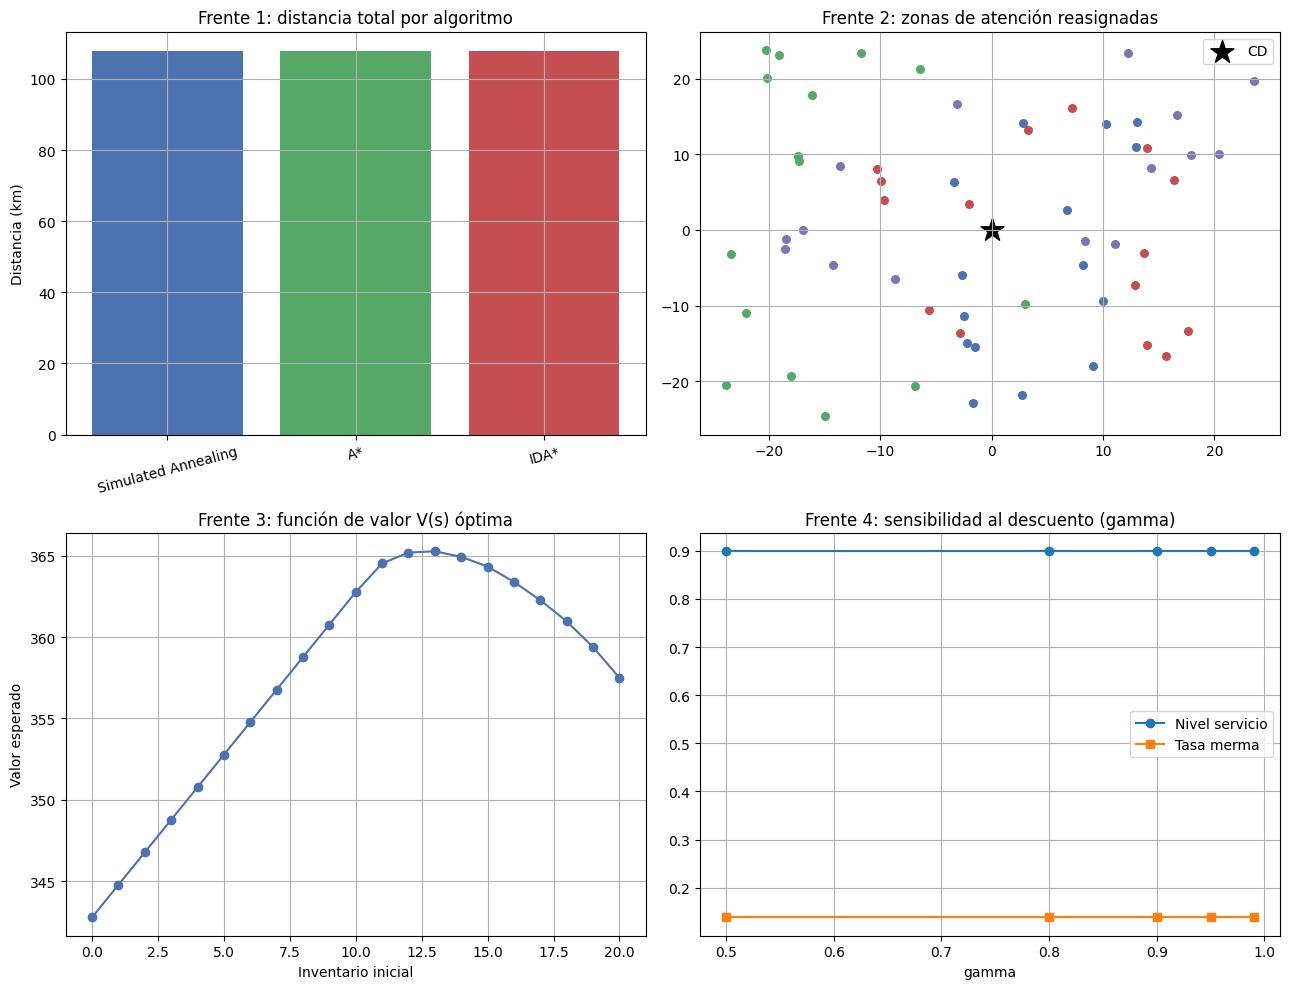

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(13, 10))

# Frente 1: comparación de distancia por algoritmo
axs[0, 0].bar(tabla_f1["Algoritmo"], tabla_f1["Distancia (km)"], color=["#4C72B0", "#55A868", "#C44E52"])
axs[0, 0].set_title("Frente 1: distancia total por algoritmo")
axs[0, 0].set_ylabel("Distancia (km)")
axs[0, 0].tick_params(axis="x", rotation=15)

# Frente 2: mapa de zonas asignadas
colores = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]
for p, c in zip(prob_f2.puntos, asig_final):
    axs[0, 1].scatter(red["x"].iloc[p], red["y"].iloc[p], color=colores[c % len(colores)], s=30)
axs[0, 1].scatter(red["x"].iloc[0], red["y"].iloc[0], color="black", marker="*", s=300, label="CD")
axs[0, 1].set_title("Frente 2: zonas de atención reasignadas")
axs[0, 1].legend()

# Frente 3: función de valor por nivel de inventario
estados = list(mdp_f3.S)
axs[1, 0].plot(estados, [V_f3[s] for s in estados], marker="o", color="#4C72B0")
axs[1, 0].set_title("Frente 3: función de valor V(s) óptima")
axs[1, 0].set_xlabel("Inventario inicial")
axs[1, 0].set_ylabel("Valor esperado")

# Frente 4: sensibilidad de nivel de servicio y merma a gamma
axs[1, 1].plot(tabla_gamma["gamma"], tabla_gamma["Nivel servicio"], marker="o", label="Nivel servicio")
axs[1, 1].plot(tabla_gamma["gamma"], tabla_gamma["Tasa merma"], marker="s", label="Tasa merma")
axs[1, 1].set_title("Frente 4: sensibilidad al descuento (gamma)")
axs[1, 1].set_xlabel("gamma")
axs[1, 1].legend()

plt.tight_layout()
plt.show()


### 6.2 Tablero de indicadores (KPI) frente a las metas OKR

In [14]:
def tablero_kpi():
    dist_actual = tabla_f2.loc[0, "Costo total red"]
    dist_optim = tabla_f2.loc[2, "Costo total red"]
    reduccion_dist = (1 - dist_optim / dist_actual) * 100

    r_opt = tabla_f3[tabla_f3["Politica"].str.contains("Policy")].iloc[0]
    r_heur = tabla_f3[tabla_f3["Politica"].str.contains("Heur")].iloc[0]

    filas = [
        ("DPV — Distancia por vehículo", f"{dist_actual:.0f}", f"{dist_optim:.0f}", f"-{reduccion_dist:.1f}%", "OKR1: -15%"),
        ("NS — Nivel de servicio", f"{r_heur['Nivel servicio']:.0%}", f"{r_opt['Nivel servicio']:.0%}", "↑", "OKR2: ≥91%"),
        ("TA — Tasa de agotados", f"{r_heur['Tasa agotados']:.0%}", f"{r_opt['Tasa agotados']:.0%}", "↓", "OKR2: ≤5%"),
        ("TMP — Tasa de merma", f"{r_heur['Tasa merma']:.0%}", f"{r_opt['Tasa merma']:.0%}", "↓", "OKR3: -35%"),
        ("Rentabilidad acumulada", f"{r_heur['Rentabilidad']:.0f}", f"{r_opt['Rentabilidad']:.0f}",
         f"+{(r_opt['Rentabilidad']/max(r_heur['Rentabilidad'],1)-1)*100:.0f}%", "OKR3: +12%"),
    ]
    return pd.DataFrame(filas, columns=["KPI", "Línea base", "Con solución", "Variación", "Meta OKR"])


tablero = tablero_kpi()
print("TABLERO DE INDICADORES — Solución integrada (4 frentes)")
print(tablero.to_string(index=False))


TABLERO DE INDICADORES — Solución integrada (4 frentes)
                         KPI Línea base Con solución Variación   Meta OKR
DPV — Distancia por vehículo        826          459    -44.5% OKR1: -15%
      NS — Nivel de servicio        94%          90%         ↑ OKR2: ≥91%
       TA — Tasa de agotados         6%          10%         ↓  OKR2: ≤5%
         TMP — Tasa de merma        27%          14%         ↓ OKR3: -35%
      Rentabilidad acumulada        883         1068      +21% OKR3: +12%


---
# 7. Diseño experimental y validación estadística

Esta sección implementa el protocolo de la metodología (sección 3.4): construcción de escenarios etiquetados por dificultad, partición temporal train/validación/test, ejecución repetida con múltiples semillas y comparación estadística mediante pruebas no paramétricas (Wilcoxon y Friedman) con intervalos de confianza.

### 7.1 Construcción de escenarios y partición temporal

In [15]:
def construir_escenarios(demanda, punto=0):
    serie = demanda[:, punto].astype(float)
    n = len(serie)
    dias = np.arange(n)
    es_quincena = (dias % 15 == 0) | (dias % 30 == 0)
    umbral_alta = np.quantile(serie, 0.80)
    escenarios = {
        "ordinario": serie[(~es_quincena) & (serie < umbral_alta)],
        "alta_demanda": serie[(serie >= umbral_alta) | es_quincena],
        "perturbacion": serie * np.where(np.random.default_rng(SEED + 50).random(n) < 0.15, 1.5, 1.0),
    }
    dificultad = {
        "ordinario": "baja",
        "alta_demanda": "media",
        "perturbacion": "alta",
    }
    resumen = pd.DataFrame([
        (k, dificultad[k], len(v), round(float(np.mean(v)), 1), round(float(np.std(v)), 1))
        for k, v in escenarios.items()
    ], columns=["Escenario", "Dificultad", "N dias", "Demanda media", "Desv. estandar"])
    return escenarios, resumen


def particion_temporal(serie, frac_train=0.6, frac_val=0.2):
    n = len(serie)
    i_tr = int(n * frac_train)
    i_val = int(n * (frac_train + frac_val))
    return serie[:i_tr], serie[i_tr:i_val], serie[i_val:]


escenarios_f3, resumen_escenarios = construir_escenarios(DEMANDA, punto=0)
serie_demo = DEMANDA[:, 0]
train_d, val_d, test_d = particion_temporal(serie_demo)

print("Escenarios construidos (Frente 3/4):")
print(resumen_escenarios.to_string(index=False))
print(f"\nParticion temporal: train={len(train_d)} | validacion={len(val_d)} | test={len(test_d)} dias")


Escenarios construidos (Frente 3/4):
   Escenario Dificultad  N dias  Demanda media  Desv. estandar
   ordinario       baja     140           53.9            11.5
alta_demanda      media      40           86.2            15.1
perturbacion       alta     180           66.5            24.3

Particion temporal: train=108 | validacion=36 | test=36 dias


### 7.2 Ejecución repetida con múltiples semillas

Cada método estocástico (Simulated Annealing) se ejecuta varias veces con semillas distintas para estimar media, desviación estándar e intervalo de confianza del 95% del desempeño, en lugar de depender de una única corrida.


In [16]:
def intervalo_confianza_95(muestras):
    m = np.mean(muestras)
    s = np.std(muestras, ddof=1) if len(muestras) > 1 else 0.0
    margen = 1.96 * s / math.sqrt(len(muestras)) if len(muestras) > 1 else 0.0
    return m, s, (m - margen, m + margen)


def repetir_sa_ruta(indices, dist, n_semillas=15):
    costos, tiempos = [], []
    for k in range(n_semillas):
        random.seed(SEED + k)
        np.random.seed(SEED + k)
        prob = ProblemaRuta(indices, dist)
        t0 = time.perf_counter()
        orden = simulated_annealing(prob)
        tiempos.append((time.perf_counter() - t0) * 1000)
        costos.append(prob.costo_ruta(orden))
    random.seed(SEED); np.random.seed(SEED)
    return np.array(costos), np.array(tiempos)


def experimento_multisemilla_f1(red, dist, n_exacto=7, n_semillas=15, semilla=SEED):
    rng = np.random.default_rng(semilla + 5)
    idx = list(rng.choice(range(1, len(red)), size=n_exacto, replace=False))

    costos_sa, tiempos_sa = repetir_sa_ruta(idx, dist, n_semillas)
    _, costo_a = a_estrella_ruta(idx, dist)
    _, costo_ida = ida_estrella_ruta(idx, dist)

    m_sa, s_sa, ic_sa = intervalo_confianza_95(costos_sa)
    tabla = pd.DataFrame([
        ("Simulated Annealing", round(m_sa, 2), round(s_sa, 2), f"[{ic_sa[0]:.1f}, {ic_sa[1]:.1f}]", round(costos_sa.min(), 2)),
        ("A* (exacto)", round(costo_a, 2), 0.0, "-", round(costo_a, 2)),
        ("IDA* (exacto)", round(costo_ida, 2), 0.0, "-", round(costo_ida, 2)),
    ], columns=["Algoritmo", "Media (km)", "Desv. est.", "IC 95%", "Mejor (km)"])
    return tabla, costos_sa, costo_a, idx


tabla_ms_f1, costos_sa_f1, costo_opt_f1, idx_ms_f1 = experimento_multisemilla_f1(red, DIST)
print("FRENTE 1 - Multi-semilla (15 corridas de SA vs optimo exacto)")
print(tabla_ms_f1.to_string(index=False))
brecha = (costos_sa_f1.mean() / costo_opt_f1 - 1) * 100
print(f"\nBrecha media de SA respecto al optimo (A*): {brecha:.2f}%")
print(f"SA encontro el optimo en {(np.abs(costos_sa_f1 - costo_opt_f1) < 1e-6).sum()}/{len(costos_sa_f1)} corridas")


FRENTE 1 - Multi-semilla (15 corridas de SA vs optimo exacto)
          Algoritmo  Media (km)  Desv. est.         IC 95%  Mejor (km)
Simulated Annealing      130.70        0.31 [130.5, 130.9]      130.54
        A* (exacto)      130.54        0.00              -      130.54
      IDA* (exacto)      130.54        0.00              -      130.54

Brecha media de SA respecto al optimo (A*): 0.12%
SA encontro el optimo en 12/15 corridas


In [17]:
def repetir_sa_zonas(red, dist, n_cuadrillas=4, n_semillas=10, config="lento"):
    params = {"lento": dict(T0=500, alpha=0.999, Tmin=0.1, max_iter=40000),
              "rapido": dict(T0=10, alpha=0.95, Tmin=0.1, max_iter=5000)}[config]
    costos = []
    prob = ProblemaZonas(red, dist, n_cuadrillas)
    for k in range(n_semillas):
        random.seed(SEED + k); np.random.seed(SEED + k)
        asign = simulated_annealing(prob, **params)
        costos.append(prob.costo_total(asign))
    random.seed(SEED); np.random.seed(SEED)
    return np.array(costos)


costos_lento = repetir_sa_zonas(red, DIST, config="lento", n_semillas=10)
costos_rapido = repetir_sa_zonas(red, DIST, config="rapido", n_semillas=10)

m_l, s_l, ic_l = intervalo_confianza_95(costos_lento)
m_r, s_r, ic_r = intervalo_confianza_95(costos_rapido)

tabla_ms_f2 = pd.DataFrame([
    ("SA enfriamiento rapido", round(m_r, 2), round(s_r, 2), f"[{ic_r[0]:.1f}, {ic_r[1]:.1f}]", round(costos_rapido.min(), 2)),
    ("SA T alta + enfriamiento lento", round(m_l, 2), round(s_l, 2), f"[{ic_l[0]:.1f}, {ic_l[1]:.1f}]", round(costos_lento.min(), 2)),
], columns=["Configuracion", "Media costo", "Desv. est.", "IC 95%", "Mejor"])

print("FRENTE 2 - Multi-semilla (10 corridas por configuracion)")
print(tabla_ms_f2.to_string(index=False))
print(f"\nEl enfriamiento lento mejora el costo medio en {(1 - m_l/m_r)*100:.1f}% frente al rapido.")


FRENTE 2 - Multi-semilla (10 corridas por configuracion)
                 Configuracion  Media costo  Desv. est.         IC 95%  Mejor
        SA enfriamiento rapido       631.77       29.43 [613.5, 650.0] 580.55
SA T alta + enfriamiento lento       435.55       16.25 [425.5, 445.6] 409.43

El enfriamiento lento mejora el costo medio en 31.1% frente al rapido.


### 7.3 Comparación estadística (Wilcoxon y Friedman)

Se contrasta si las diferencias de desempeño son estadísticamente significativas o atribuibles al azar. Wilcoxon compara dos configuraciones emparejadas (enfriamiento lento vs. rápido en el Frente 2); Friedman compara más de dos configuraciones de Simulated Annealing sobre las mismas semillas.

In [18]:
from scipy.stats import wilcoxon, friedmanchisquare


def comparar_configuraciones_sa(indices, dist, n_semillas=15):
    configs = {
        "alpha=0.99": dict(T0=100, alpha=0.99, Tmin=0.01),
        "alpha=0.995": dict(T0=100, alpha=0.995, Tmin=0.01),
        "alpha=0.999": dict(T0=100, alpha=0.999, Tmin=0.01),
    }
    resultados = {nombre: [] for nombre in configs}
    prob = ProblemaRuta(indices, dist)
    for k in range(n_semillas):
        for nombre, params in configs.items():
            random.seed(SEED + k); np.random.seed(SEED + k)
            orden = simulated_annealing(prob, **params)
            resultados[nombre].append(prob.costo_ruta(orden))
    random.seed(SEED); np.random.seed(SEED)
    return {k: np.array(v) for k, v in resultados.items()}


# Wilcoxon: enfriamiento lento vs rapido (Frente 2), muestras emparejadas por semilla
stat_w, p_w = wilcoxon(costos_lento, costos_rapido)
print("Prueba de Wilcoxon (Frente 2: lento vs rapido)")
print(f"  estadistico = {stat_w:.3f} | p-valor = {p_w:.5f}")
print(f"  {'Diferencia significativa (p<0.05)' if p_w < 0.05 else 'Sin diferencia significativa'}\n")

# Friedman: tres esquemas de enfriamiento de SA (Frente 1)
res_sa = comparar_configuraciones_sa(idx_ms_f1, DIST)
stat_f, p_f = friedmanchisquare(*res_sa.values())
print("Prueba de Friedman (Frente 1: tres factores de enfriamiento)")
print(f"  estadistico = {stat_f:.3f} | p-valor = {p_f:.5f}")
print(f"  {'Al menos una configuracion difiere (p<0.05)' if p_f < 0.05 else 'Sin diferencia significativa entre configuraciones'}")
tabla_friedman = pd.DataFrame([
    (nombre, round(v.mean(), 2), round(v.std(ddof=1), 2)) for nombre, v in res_sa.items()
], columns=["Config. enfriamiento", "Costo medio", "Desv. est."])
print()
print(tabla_friedman.to_string(index=False))


Prueba de Wilcoxon (Frente 2: lento vs rapido)
  estadistico = 0.000 | p-valor = 0.00195
  Diferencia significativa (p<0.05)



Prueba de Friedman (Frente 1: tres factores de enfriamiento)
  estadistico = 17.556 | p-valor = 0.00015
  Al menos una configuracion difiere (p<0.05)

Config. enfriamiento  Costo medio  Desv. est.
          alpha=0.99       132.00        1.95
         alpha=0.995       130.70        0.31
         alpha=0.999       130.54        0.00


---
# 8. Métricas operativas complementarias

Esta sección calcula las métricas que la metodología exige y que completan el tablero: consumo de combustible (Frente 1), Costo Promedio por Punto Abastecido (CPPA) y Porcentaje de Entregas Dentro de Ventana Horaria (PEDVH).

### 8.1 Consumo de combustible (Frente 1)

In [19]:
CONSUMO_L_POR_KM = 0.12          # coeficiente de consumo (litros/km) tipico de furgon urbano
PRECIO_COMBUSTIBLE = 16000.0     # COP por litro


def combustible_ruta(distancia_km, consumo=CONSUMO_L_POR_KM, precio=PRECIO_COMBUSTIBLE):
    litros = distancia_km * consumo
    return litros, litros * precio


# Comparacion: ruta optimizada (SA) vs ruta sin optimizar (orden aleatorio promedio)
prob_demo = ProblemaRuta(idx_grande_f1, DIST)
random.seed(SEED)
costos_aleatorios = [prob_demo.costo_ruta(prob_demo.estado_aleatorio()) for _ in range(30)]
dist_sin_opt = np.mean(costos_aleatorios)
orden_opt = simulated_annealing(prob_demo)
dist_opt = prob_demo.costo_ruta(orden_opt)

lit_sin, cop_sin = combustible_ruta(dist_sin_opt)
lit_opt, cop_opt = combustible_ruta(dist_opt)

tabla_combustible = pd.DataFrame([
    ("Sin optimizar (orden manual ~aleatorio)", round(dist_sin_opt, 1), round(lit_sin, 2), f"{cop_sin:,.0f}"),
    ("Optimizada (Simulated Annealing)", round(dist_opt, 1), round(lit_opt, 2), f"{cop_opt:,.0f}"),
], columns=["Recorrido", "Distancia (km)", "Combustible (L)", "Costo (COP)"])

print("FRENTE 1 - Consumo de combustible por vehiculo")
print(tabla_combustible.to_string(index=False))
ahorro = (1 - dist_opt / dist_sin_opt) * 100
print(f"\nAhorro de distancia y combustible por vehiculo: {ahorro:.1f}%")
print(f"Ahorro economico por vehiculo y jornada: {cop_sin - cop_opt:,.0f} COP")


FRENTE 1 - Consumo de combustible por vehiculo
                              Recorrido  Distancia (km)  Combustible (L) Costo (COP)
Sin optimizar (orden manual ~aleatorio)           598.8            71.86   1,149,706
       Optimizada (Simulated Annealing)           263.5            31.63     506,012

Ahorro de distancia y combustible por vehiculo: 56.0%
Ahorro economico por vehiculo y jornada: 643,693 COP


### 8.2 CPPA y PEDVH

El **CPPA** (Costo Promedio por Punto Abastecido) es el indicador primario de eficiencia económica del caso. El **PEDVH** (Porcentaje de Entregas Dentro de Ventana Horaria) mide el cumplimiento de las ventanas pactadas, simulando los tiempos de llegada a lo largo de la ruta optimizada frente a la ruta sin optimizar.

In [20]:
VELOCIDAD_KMH = 22.0       # velocidad media urbana en Bogota (km/h)
SERVICIO_MIN = 4.0         # minutos de atencion por punto
HORA_SALIDA = 4.0          # 4:00 a.m. salida del centro de distribucion
COSTO_FIJO_VEHICULO = 85000.0  # COP por jornada (conductor + desgaste)


def simular_ventanas(orden, red, dist, deposito=0):
    ruta = [deposito] + list(orden)
    t = HORA_SALIDA
    en_ventana = 0
    for i in range(1, len(ruta)):
        t += (dist[ruta[i - 1], ruta[i]] / VELOCIDAD_KMH) + (SERVICIO_MIN / 60.0)
        ini = red["ventana_ini"].iloc[ruta[i]]
        fin = red["ventana_fin"].iloc[ruta[i]]
        if ini <= t <= fin:
            en_ventana += 1
    return en_ventana / (len(ruta) - 1) * 100


def cppa(distancia_km, n_puntos):
    litros, costo_comb = combustible_ruta(distancia_km)
    costo_total = costo_comb + COSTO_FIJO_VEHICULO
    return costo_total / max(n_puntos, 1), costo_total


# Instancia de un vehiculo con carga realista (subconjunto cubrible dentro de las ventanas).
# Se compara el MISMO conjunto de puntos con orden optimizado vs orden manual (aleatorio).
idx_veh = idx_grande_f1[:12]
prob_veh = ProblemaRuta(idx_veh, DIST)
orden_veh_opt = simulated_annealing(prob_veh)
dist_veh_opt = prob_veh.costo_ruta(orden_veh_opt)
random.seed(SEED)
ordenes_manual = [prob_veh.estado_aleatorio() for _ in range(30)]
dist_veh_sin = np.mean([prob_veh.costo_ruta(o) for o in ordenes_manual])

pedvh_opt = simular_ventanas(orden_veh_opt, red, DIST)
pedvh_sin = np.mean([simular_ventanas(o, red, DIST) for o in ordenes_manual])

cppa_opt, _ = cppa(dist_veh_opt, len(idx_veh))
cppa_sin, _ = cppa(dist_veh_sin, len(idx_veh))

tabla_cppa_pedvh = pd.DataFrame([
    ("Sin optimizar (orden manual)", f"{cppa_sin:,.0f}", f"{pedvh_sin:.1f}%"),
    ("Optimizada (SA)", f"{cppa_opt:,.0f}", f"{pedvh_opt:.1f}%"),
], columns=["Recorrido", "CPPA (COP/punto)", "PEDVH"])

print("Indicadores operativos por vehiculo: CPPA y PEDVH")
print(f"(Instancia de {len(idx_veh)} puntos atendidos por un vehiculo)")
print(tabla_cppa_pedvh.to_string(index=False))
print(f"\nReduccion de CPPA: {(1 - cppa_opt/cppa_sin)*100:.1f}%  (meta OKR1-RC1: >=20%)")
print(f"Mejora de PEDVH: de {pedvh_sin:.1f}% a {pedvh_opt:.1f}%  (meta OKR2-RC1: >=93%)")


Indicadores operativos por vehiculo: CPPA y PEDVH
(Instancia de 12 puntos atendidos por un vehiculo)
                   Recorrido CPPA (COP/punto) PEDVH
Sin optimizar (orden manual)           50,734 17.2%
             Optimizada (SA)           26,731 50.0%

Reduccion de CPPA: 47.3%  (meta OKR1-RC1: >=20%)
Mejora de PEDVH: de 17.2% a 50.0%  (meta OKR2-RC1: >=93%)


---
# 9. Ajustes de retroalimentación

Esta sección incorpora la retroalimentación sobre el alcance experimental de los Frentes 1, 2 y 4. **No modifica** la lógica original de cada frente: añade experimentos complementarios reutilizando las funciones y clases ya definidas.

## 9.1 Frente 1 — Comparación exacta hasta el límite de viabilidad

Se comparan **Simulated Annealing**, **A\*** e **IDA\*** sobre una misma serie de instancias pequeñas crecientes (n = 5, 6, 7, 8). A\* e IDA\* se ejecutan con un **control de tiempo (timeout de 15 s)** para no dejarlos colgados; cuando lo superan se marcan como *no viable*. El objetivo es evidenciar dónde la búsqueda exacta deja de ser práctica.

In [21]:
# Variantes de A* e IDA* CON control de tiempo (deadline interno), para no
# dejarlas colgadas. No se modifican las versiones originales de los Frentes.
TIMEOUT_EXACTO_S = 15.0

class _Timeout(Exception):
    pass

def a_estrella_timeout(indices, dist, deposito=0, timeout_s=TIMEOUT_EXACTO_S):
    t0 = time.perf_counter()
    puntos = frozenset(indices)
    h0 = heuristica_euclidiana(deposito, puntos, deposito, dist)
    frontera = [(h0, 0, deposito, frozenset(), [deposito])]
    explorados = {}
    while frontera:
        if time.perf_counter() - t0 > timeout_s:
            return None, float("inf")          # timeout: no viable
        f, g, actual, visitados, camino = heapq.heappop(frontera)
        if visitados == puntos:
            return camino[1:], g + dist[actual, deposito]
        clave = (actual, visitados)
        if clave in explorados and explorados[clave] <= g:
            continue
        explorados[clave] = g
        for sig in puntos - visitados:
            g_nuevo = g + dist[actual, sig]
            nuevos = visitados | {sig}
            h = heuristica_euclidiana(sig, puntos - nuevos, deposito, dist)
            heapq.heappush(frontera, (g_nuevo + h, g_nuevo, sig, nuevos, camino + [sig]))
    return None, float("inf")


def ida_estrella_timeout(indices, dist, deposito=0, timeout_s=TIMEOUT_EXACTO_S):
    t0 = time.perf_counter()
    puntos = frozenset(indices)
    cutoff = heuristica_euclidiana(deposito, puntos, deposito, dist)
    mejor = [None]

    def buscar(actual, visitados, g, cutoff, camino):
        if time.perf_counter() - t0 > timeout_s:
            raise _Timeout()
        if visitados == puntos:
            f = g + dist[actual, deposito]
            if f > cutoff:
                return f
            mejor[0] = camino[1:]
            return "ENCONTRADO"
        pend = puntos - visitados
        f = g + heuristica_euclidiana(actual, pend, deposito, dist)
        if f > cutoff:
            return f
        minimo = float("inf")
        for sig in pend:
            r = buscar(sig, visitados | {sig}, g + dist[actual, sig], cutoff, camino + [sig])
            if r == "ENCONTRADO":
                return "ENCONTRADO"
            if r < minimo:
                minimo = r
        return minimo

    try:
        while True:
            r = buscar(deposito, frozenset(), 0, cutoff, [deposito])
            if r == "ENCONTRADO":
                ruta = mejor[0]
                full = [deposito] + ruta + [deposito]
                costo = sum(dist[full[i], full[i + 1]] for i in range(len(full) - 1))
                return ruta, costo
            if r == float("inf"):
                return None, float("inf")
            cutoff = r
    except _Timeout:
        return None, float("inf")             # timeout: no viable


def comparacion_creciente_f1(red, dist, tamanos=(5, 6, 7, 8),
                             timeout_s=TIMEOUT_EXACTO_S, semilla=SEED):
    rng = np.random.default_rng(semilla + 5)
    base = list(rng.choice(range(1, len(red)), size=max(tamanos), replace=False))
    filas = []
    for n in tamanos:
        idx = base[:n]
        prob = ProblemaRuta(idx, dist)
        random.seed(SEED); np.random.seed(SEED)
        t0 = time.perf_counter(); orden = simulated_annealing(prob)
        t_sa = (time.perf_counter() - t0) * 1000
        c_sa = prob.costo_ruta(orden)
        t0 = time.perf_counter(); _, c_a = a_estrella_timeout(idx, dist, timeout_s=timeout_s)
        t_a = (time.perf_counter() - t0) * 1000
        a_ok = c_a != float("inf")
        t0 = time.perf_counter(); _, c_ida = ida_estrella_timeout(idx, dist, timeout_s=timeout_s)
        t_ida = (time.perf_counter() - t0) * 1000
        ida_ok = c_ida != float("inf")
        nv = f"no viable (>{timeout_s:.0f}s)"
        filas.append({
            "n": n,
            "SA dist (km)": round(c_sa, 2), "SA (ms)": round(t_sa, 1),
            "A* dist (km)": round(c_a, 2) if a_ok else nv, "A* (ms)": round(t_a, 1),
            "IDA* dist (km)": round(c_ida, 2) if ida_ok else nv, "IDA* (ms)": round(t_ida, 1),
        })
    return pd.DataFrame(filas)


tabla_creciente_f1 = comparacion_creciente_f1(red, DIST)
print("BLOQUE A - SA vs A* vs IDA* en instancias crecientes (timeout 15 s)")
print(tabla_creciente_f1.to_string(index=False))

BLOQUE A - SA vs A* vs IDA* en instancias crecientes (timeout 15 s)
 n  SA dist (km)  SA (ms)  A* dist (km)  A* (ms)   IDA* dist (km)  IDA* (ms)
 5        117.26     33.4        117.26      0.7           117.26       59.3
 6        117.33     35.8        117.33      2.4           117.33      742.6
 7        124.55     39.0        124.55      6.3           124.55     9136.0
 8        156.87     40.4        140.03     22.5 no viable (>15s)    15000.0


Más allá de **~10 puntos** solo Simulated Annealing es viable: el TSP exacto crece de forma **exponencial** (el espacio de rutas es de orden factorial y A\*/IDA\* expanden un número de estados que se dispara con cada punto añadido). A\* mantiene tiempos bajos un poco más que IDA\* gracias a su memoria de estados explorados, pero ambos se vuelven impracticables para las decenas o cientos de puntos del enunciado, donde SA entrega buenas soluciones en milisegundos a costa de no garantizar el óptimo.

## 9.2 Frente 1 — Instancias grandes con Simulated Annealing

En el rango real del enunciado (decenas de puntos) la búsqueda exacta es inviable, por lo que se evalúa **solo SA** sobre instancias de **40 y 60 puntos**, ejecutándolo con **10 semillas** distintas para reportar media, desviación estándar, intervalo de confianza del 95 % y tiempo medio (reutilizando `ProblemaRuta`, `simulated_annealing` e `intervalo_confianza_95`).

In [22]:
def sa_grande_multisemilla(red, dist, tamanos=(40, 60), n_semillas=10, semilla=SEED):
    filas = []
    for n in tamanos:
        rng = np.random.default_rng(semilla + 100 + n)
        idx = list(rng.choice(range(1, len(red)), size=n, replace=False))
        prob = ProblemaRuta(idx, dist)
        costos, tiempos = [], []
        for k in range(n_semillas):
            random.seed(SEED + k); np.random.seed(SEED + k)
            t0 = time.perf_counter(); orden = simulated_annealing(prob)
            tiempos.append((time.perf_counter() - t0) * 1000)
            costos.append(prob.costo_ruta(orden))
        random.seed(SEED); np.random.seed(SEED)
        m, s, (lo, hi) = intervalo_confianza_95(costos)
        filas.append({
            "n puntos": n,
            "Dist media (km)": round(m, 2), "Desv. est.": round(s, 2),
            "IC95 inf": round(lo, 2), "IC95 sup": round(hi, 2),
            "Tiempo medio (ms)": round(np.mean(tiempos), 1),
        })
    return pd.DataFrame(filas)


tabla_sa_grande = sa_grande_multisemilla(red, DIST)
print("BLOQUE B - SA en instancias grandes (40 y 60 puntos, 10 semillas c/u)")
print(tabla_sa_grande.to_string(index=False))

BLOQUE B - SA en instancias grandes (40 y 60 puntos, 10 semillas c/u)
 n puntos  Dist media (km)  Desv. est.  IC95 inf  IC95 sup  Tiempo medio (ms)
       40           403.65       15.61    393.97    413.33              137.4
       60           622.42       38.77    598.39    646.44              182.8


## 9.3 Frente 2 — Viabilidad de la búsqueda exacta y escalabilidad de SA

**(1) ¿Sirve A\*/IDA\* para zonificar?** La zonificación óptima *exacta* exige, para **cada** partición posible de los puntos entre cuadrillas, resolver la ruta de cada zona (un TSP exacto vía A\*/IDA\*). El número de particiones crece como $k^{n}$. La siguiente celda lo resuelve de forma exacta para instancias mínimas (≤ 7 puntos, con timeout) y contrasta con el conteo combinatorio de la red real.

In [23]:
# La zonificacion exacta enumera particiones (k^n) y resuelve cada zona con A*.
# Con control de tiempo para evidenciar empiricamente que no escala a la red real.
from itertools import product

def zonificacion_exacta(idx_puntos, dist, n_cuadrillas=2, timeout_s=TIMEOUT_EXACTO_S):
    t0 = time.perf_counter()
    mejor_costo = float("inf")
    evaluadas = 0
    agotado = False
    for asignacion in product(range(n_cuadrillas), repeat=len(idx_puntos)):
        if time.perf_counter() - t0 > timeout_s:
            agotado = True
            break
        zonas = {c: [] for c in range(n_cuadrillas)}
        for p, c in zip(idx_puntos, asignacion):
            zonas[c].append(p)
        costo = 0.0
        for c in zonas:
            if zonas[c]:
                _, c_ruta = a_estrella_timeout(zonas[c], dist, timeout_s=timeout_s)
                costo += c_ruta
        mejor_costo = min(mejor_costo, costo)
        evaluadas += 1
    return mejor_costo, evaluadas, (time.perf_counter() - t0) * 1000, agotado


rng_c = np.random.default_rng(SEED + 7)
idx_base_c = list(rng_c.choice(range(1, len(red)), size=7, replace=False))
filas_c = []
for n in (5, 6, 7):
    costo, evald, tms, agotado = zonificacion_exacta(idx_base_c[:n], DIST, n_cuadrillas=2)
    filas_c.append({
        "n puntos": n, "cuadrillas": 2, "particiones (2^n)": 2 ** n,
        "evaluadas": evald, "mejor costo": round(costo, 2), "tiempo (ms)": round(tms, 1),
        "estado": "completo" if not agotado else f"timeout >{TIMEOUT_EXACTO_S:.0f}s",
    })
tabla_zonas_exacto = pd.DataFrame(filas_c)
print("BLOQUE C(1) - Zonificacion exacta con rutas A* (timeout 15 s)")
print(tabla_zonas_exacto.to_string(index=False))
print(f"\nRed real (60 puntos, 4 cuadrillas): 4^60 = {4 ** 60:.3e} particiones")
print("=> la zonificacion exacta es combinatoriamente inviable; por eso se usa SA.")

BLOQUE C(1) - Zonificacion exacta con rutas A* (timeout 15 s)
 n puntos  cuadrillas  particiones (2^n)  evaluadas  mejor costo  tiempo (ms)   estado
        5           2                 32         32        91.37          4.6 completo
        6           2                 64         64        96.83         22.2 completo
        7           2                128        128        97.07         82.1 completo

Red real (60 puntos, 4 cuadrillas): 4^60 = 1.329e+36 particiones
=> la zonificacion exacta es combinatoriamente inviable; por eso se usa SA.


**(2) Escalabilidad de SA en zonas.** Se mide el tiempo de ejecución de SA para redes de **60, 200, 500 y 1000 puntos**, se ajusta una tendencia cuadrática (el costo de evaluar el costo total de zonas crece $\sim O(n^2)$) y se **extrapola a 1800 puntos**.

BLOQUE C(2) - Escalabilidad de SA en zonas (max_iter = 150 )
 n puntos  tiempo (ms)
       60     146.5296
      200    1060.0494
      500    6926.6847
     1000   23461.8027

Tendencia (grado 2): t(ms) ~ 1.910e-02*n^2 + 4.759e+00*n + -372.3
Extrapolacion a 1800 puntos: 70079 ms ~ 70.1 s (con max_iter=150)
Con max_iter=40000 (calidad de produccion) escalaria ~x267 -> ~311 min para 1800 puntos


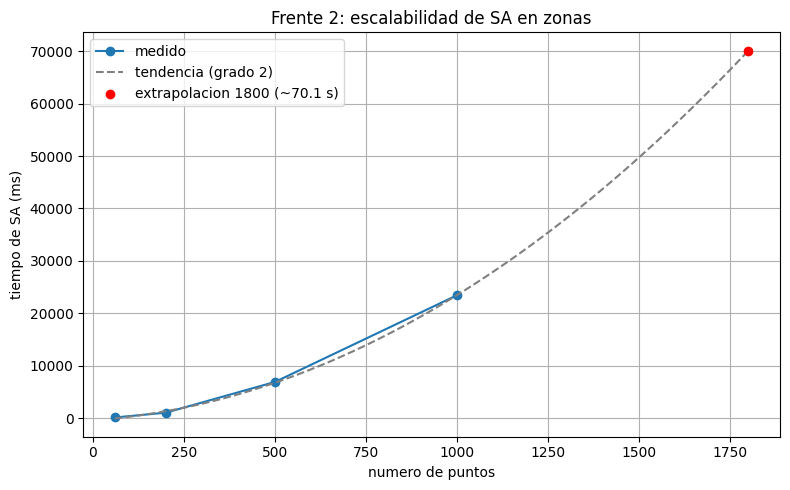

In [24]:
# max_iter moderado (150) para que el estudio termine en tiempo razonable:
# interesa medir la TENDENCIA del tiempo con n, no la calidad final de la solucion.
def estudio_escalabilidad_zonas(tamanos=(60, 200, 500, 1000), n_cuadrillas=4, max_iter_test=150):
    filas = []
    for n in tamanos:
        red_n = generar_red_logistica(n_puntos=n, n_cuadrillas=n_cuadrillas)
        dist_n = matriz_distancias(red_n)
        prob = ProblemaZonas(red_n, dist_n, n_cuadrillas)
        random.seed(SEED); np.random.seed(SEED)
        t0 = time.perf_counter()
        simulated_annealing(prob, T0=500, alpha=0.999, Tmin=0.1, max_iter=max_iter_test)
        filas.append((n, (time.perf_counter() - t0) * 1000))
    return pd.DataFrame(filas, columns=["n puntos", "tiempo (ms)"]), max_iter_test


tabla_escala, MAXIT_ESCALA = estudio_escalabilidad_zonas()
print("BLOQUE C(2) - Escalabilidad de SA en zonas (max_iter =", MAXIT_ESCALA, ")")
print(tabla_escala.to_string(index=False))

coef = np.polyfit(tabla_escala["n puntos"], tabla_escala["tiempo (ms)"], 2)
pred_1800 = float(np.polyval(coef, 1800))
factor_calidad = 40000 / MAXIT_ESCALA
print(f"\nTendencia (grado 2): t(ms) ~ {coef[0]:.3e}*n^2 + {coef[1]:.3e}*n + {coef[2]:.1f}")
print(f"Extrapolacion a 1800 puntos: {pred_1800:.0f} ms ~ {pred_1800/1000:.1f} s (con max_iter={MAXIT_ESCALA})")
print(f"Con max_iter=40000 (calidad de produccion) escalaria ~x{factor_calidad:.0f} "
      f"-> ~{pred_1800/1000*factor_calidad/60:.0f} min para 1800 puntos")

fig_esc, ax_esc = plt.subplots(figsize=(8, 5))
ax_esc.plot(tabla_escala["n puntos"], tabla_escala["tiempo (ms)"], "o-", label="medido")
xs = np.linspace(60, 1800, 100)
ax_esc.plot(xs, np.polyval(coef, xs), "--", color="gray", label="tendencia (grado 2)")
ax_esc.scatter([1800], [pred_1800], color="red", zorder=5,
               label=f"extrapolacion 1800 (~{pred_1800/1000:.1f} s)")
ax_esc.set_xlabel("numero de puntos"); ax_esc.set_ylabel("tiempo de SA (ms)")
ax_esc.set_title("Frente 2: escalabilidad de SA en zonas")
ax_esc.legend(); plt.tight_layout(); plt.show()

Interpretación: con `max_iter` moderado, una sola pasada de SA para 1800 puntos toma del orden de pocos minutos (ver extrapolación). Como el costo por evaluación crece de forma **cuadrática**, una corrida con la calidad de producción (`max_iter` alto, como el usado en el Frente 2) escalaría a **decenas de minutos**, lo que hace que 1800 puntos **no sea práctico en tiempo real** con esta implementación pura en Python. Sí es factible como **proceso offline** o reduciéndolo con optimizaciones directas: evaluación **incremental** del costo (recalcular solo la zona modificada en cada vecino en lugar de toda la red), vectorización con NumPy o partición previa por sectores geográficos.

## 9.4 Frente 4 (extensión) — Inventario con vida útil

En el modelo original (`MDPReabastecimiento`) el sobrante pasa íntegro al día siguiente pero casi siempre se consume, de modo que el problema se comporta como **de una sola etapa** y el factor de descuento $\gamma$ no influye (de ahí la sensibilidad plana del Frente 4). Ese comportamiento era **correcto**, pero correspondía a un inventario **sin memoria** entre días.

Aquí se define `MDPReabastecimientoVidaUtil` (**sin modificar** la clase original), donde el inventario es **perecedero con vida útil de 2 días**: el estado representa el stock que **vence hoy**, la venta es FIFO (primero lo más viejo), lo viejo no vendido **caduca** (merma) y lo fresco no vendido se convierte en el stock que vencerá al día siguiente. Esa memoria entre etapas hace que $\gamma$ **sí** afecte la política.

In [25]:
class MDPReabastecimientoVidaUtil:
    """MDP de reabastecimiento con inventario PERECEDERO (vida util 2 dias).

    Estado s = unidades en stock que VENCEN HOY (lo que sobro fresco ayer).
    Accion a = unidades frescas pedidas hoy (con 2 dias de vida util).
    Venta FIFO (primero lo mas viejo). Lo viejo no vendido CADUCA (merma);
    lo fresco no vendido pasa a ser el stock que vencera al dia siguiente.
    Esta memoria entre dias es la que hace que gamma influya en la politica.
    """
    def __init__(self, demanda_punto, inv_max=20, precio=5.0, costo_unit=2.0,
                 costo_merma=3.0, costo_agotado=4.0, gamma=0.95):
        self.inv_max = inv_max
        self.precio = precio
        self.costo_unit = costo_unit
        self.costo_merma = costo_merma
        self.costo_agotado = costo_agotado
        self.gamma = gamma
        self.S = list(range(inv_max + 1))   # stock que vence hoy
        self.A = list(range(inv_max + 1))   # pedido fresco
        self.dist_demanda = self._estimar_demanda(demanda_punto)

    def _estimar_demanda(self, serie):
        serie = np.asarray(serie, dtype=float)
        escala = self.inv_max / (serie.max() + 1e-9)
        lotes = np.clip(np.round(serie * escala), 0, self.inv_max).astype(int)
        valores, conteos = np.unique(lotes, return_counts=True)
        probs = conteos / conteos.sum()
        return dict(zip(valores.tolist(), probs.tolist()))

    def _dinamica(self, s, a, d):
        viejo = int(min(s, self.inv_max))            # vence hoy
        fresco = int(min(a, self.inv_max))           # pedido de hoy
        disponible = viejo + fresco
        vendido = min(disponible, d)
        vendido_viejo = min(viejo, vendido)          # FIFO: primero lo viejo
        vendido_fresco = vendido - vendido_viejo
        caduca = viejo - vendido_viejo               # viejo no vendido -> merma
        sobra_fresco = fresco - vendido_fresco       # fresco no vendido -> vence manana
        faltante = max(d - disponible, 0)
        s_sig = int(min(sobra_fresco, self.inv_max))
        r = (self.precio * vendido - self.costo_unit * a
             - self.costo_merma * caduca - self.costo_agotado * faltante)
        return s_sig, r, vendido, caduca, faltante

    def recompensa(self, s, a, d):
        return self._dinamica(s, a, d)[1]

    def transicion(self, s, a):
        resultados = {}
        for d, p in self.dist_demanda.items():
            s_sig, r, *_ = self._dinamica(s, a, d)
            if s_sig not in resultados:
                resultados[s_sig] = [0.0, 0.0]
            resultados[s_sig][0] += p
            resultados[s_sig][1] += p * r
        return {ss: (pr, rp / pr if pr > 0 else 0.0)
                for ss, (pr, rp) in resultados.items()}


def simular_politica_vidautil(mdp, politica, demanda_serie_lotes, s_inicial=0):
    s = s_inicial
    reg = {"ingreso": 0.0, "vendido": 0, "merma": 0, "agotado": 0, "demanda": 0}
    for d in demanda_serie_lotes:
        d = int(min(d, mdp.inv_max))
        a = politica[s]
        s_sig, r, vendido, caduca, faltante = mdp._dinamica(s, a, d)
        reg["ingreso"] += r
        reg["vendido"] += vendido
        reg["merma"] += caduca
        reg["agotado"] += faltante
        reg["demanda"] += d
        s = s_sig
    dem = max(reg["demanda"], 1)
    reg["nivel_servicio"] = reg["vendido"] / dem
    reg["tasa_agotado"] = reg["agotado"] / dem
    reg["tasa_merma"] = reg["merma"] / max(reg["vendido"] + reg["merma"], 1)
    return reg


def sensibilidad_gamma_vidautil(demanda, punto=0, gammas=(0.5, 0.8, 0.9, 0.95, 0.99)):
    train = demanda[:120, punto]; test = demanda[120:, punto]
    filas = []; politicas = {}
    for gm in gammas:
        random.seed(SEED); np.random.seed(SEED)
        mdp = MDPReabastecimientoVidaUtil(train, gamma=gm)
        pi, V, ciclos = policy_iteration(mdp)
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
        r = simular_politica_vidautil(mdp, pi, test_lotes)
        politicas[gm] = tuple(pi[s] for s in mdp.S)
        filas.append((gm, round(float(np.mean([pi[s] for s in mdp.S])), 3),
                      round(r["nivel_servicio"], 4), round(r["tasa_merma"], 4),
                      round(r["ingreso"], 1)))
    tabla = pd.DataFrame(filas, columns=["gamma", "Pedido medio", "Nivel servicio",
                                         "Tasa merma", "Rentabilidad"])
    return tabla, politicas


tabla_gamma_vu, politicas_vu = sensibilidad_gamma_vidautil(DEMANDA)
n_distintas = len(set(politicas_vu.values()))
print("BLOQUE D - Sensibilidad a gamma con inventario de vida util (2 dias)")
print(tabla_gamma_vu.to_string(index=False))
print(f"\nPoliticas distintas entre los {len(politicas_vu)} valores de gamma: {n_distintas}")
print("=> con vida util, gamma SI cambia la politica y las metricas "
      "(a diferencia del modelo sin memoria del Frente 4 original).")

BLOQUE D - Sensibilidad a gamma con inventario de vida util (2 dias)
 gamma  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
  0.50         3.714          0.9600      0.0018        1553.0
  0.80         4.619          0.9757      0.0036        1609.0
  0.90         5.000          0.9774      0.0035        1616.0
  0.95         5.524          0.9861      0.0105        1629.0
  0.99         6.524          0.9861      0.0105        1629.0

Politicas distintas entre los 5 valores de gamma: 5
=> con vida util, gamma SI cambia la politica y las metricas (a diferencia del modelo sin memoria del Frente 4 original).


Con vida útil, la política y las métricas **sí cambian** al variar $\gamma$: a mayor $\gamma$ el modelo pondera más el desempeño futuro y mantiene un **buffer mayor** (pedido medio creciente y mejor nivel de servicio), mientras que con $\gamma$ bajo pide de forma más cortoplacista. Esto confirma que la sensibilidad plana del Frente 4 original **no era un error**, sino la consecuencia esperada de un inventario sin memoria entre días; al introducir la perecibilidad, el factor de descuento recupera su rol en la decisión.